     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=f23c2042570fb66da445b38ba74f814a4e682cfdb6542698a2dfb62cf0d0cdf6
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


100%|██████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 198MiB/s]


Whisper tiny loaded. Parameters: 37,184,640
[00:00.000 --> 00:07.000]  Hello semua, my name is Piti and since I am going to learn about machine learning.

Transcription:  Hello semua, my name is Piti and since I am going to learn about machine learning.
Detected language: en


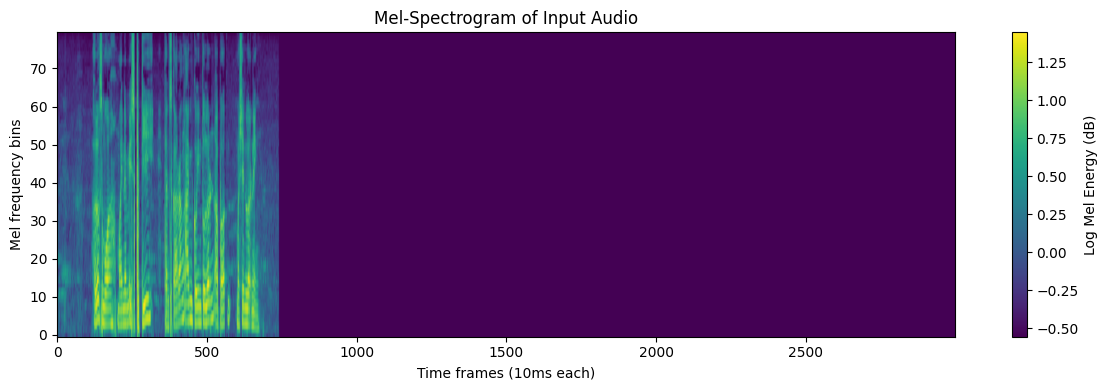


=== Multi-clip Transcription ===
[Kalimat Inggris 1] ->  Hello everyone, my name is Puti and I'm trying to record my voice.
[Kalimat Inggris 2] ->  resolika bahkan ke espai الا default dan bersising vertian måan.
[Kalimat Indonesia 1] ->  Halo semua, namasanya putih, ten saya setang mencoper ke mansuara saya.
[Kalimat Indonesia 2] ->  saya suka makan makanan petes dan berolah raka di sore hari
[Kalimat Campuran] ->  Halo guys, namassaya ada resumerti dari UK dan saya setangg mereka mai foys.

=== Word-level Timestamps ===
'Halo' [0.00s - 1.48s]
'semua,' [1.48s - 1.86s]
'meinemis' [2.26s - 2.68s]
'betih,' [2.68s - 3.52s]
'tan' [3.76s - 3.86s]
'ska' [3.86s - 4.04s]
'successful场' [4.04s - 4.32s]
'-t' [4.32s - 4.92s]
'milkshake' [4.92s - 6.34s]
'turun' [6.34s - 6.75s]


In [1]:
# 0. Instalasi Library (Jalankan ini dulu jika belum)
!pip install openai-whisper torchaudio matplotlib

import whisper
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. Load model ---
# Options: "tiny", "base", "small" (use "tiny" pada CPU, atau "base" jika pakai GPU)
model = whisper.load_model("tiny")
print(f"Whisper tiny loaded. Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- 2. Transcribe an audio file ---
# Pastikan kamu sudah mengupload file rekamanmu ke Colab
AUDIO_FILE = "/content/drive/MyDrive/Colab Notebooks/ML_M3/my_speech.wav"  # Ubah nama file ini sesuai dengan rekaman utamamu
result = model.transcribe(AUDIO_FILE, language="en", verbose=True)
print("\nTranscription:", result["text"])
print("Detected language:", result["language"])

# --- 3. Visualize the Mel-spectrogram ---
audio = whisper.load_audio(AUDIO_FILE)
audio = whisper.pad_or_trim(audio)

mel = whisper.log_mel_spectrogram(audio) # (80, 3000)

plt.figure(figsize=(12, 4))
plt.imshow(mel.numpy(), aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="Log Mel Energy (dB)")
plt.xlabel("Time frames (10ms each)")
plt.ylabel("Mel frequency bins")
plt.title("Mel-Spectrogram of Input Audio")
plt.tight_layout()
plt.savefig("mel_spectrogram.png", dpi=150)
plt.show() # Ditambahkan agar gambar langsung muncul di Colab

# --- 4. Transcribe multiple clips and compare ---
# Ubah dictionary ini dengan nama-nama file dari 5 kalimat yang sudah kamu rekam
clips = {
    "Kalimat Inggris 1": "/content/drive/MyDrive/Colab Notebooks/ML_M3/english_sample_1.wav",
    "Kalimat Inggris 2": "/content/drive/MyDrive/Colab Notebooks/ML_M3/english_sample_2.wav",
    "Kalimat Indonesia 1": "/content/drive/MyDrive/Colab Notebooks/ML_M3/indo_sample_1.wav",
    "Kalimat Indonesia 2": "/content/drive/MyDrive/Colab Notebooks/ML_M3/indo_sample_2.wav",
    "Kalimat Campuran": "/content/drive/MyDrive/Colab Notebooks/ML_M3/mixed_sample.wav",
}

print("\n=== Multi-clip Transcription ===")
for name, path in clips.items():
    try:
        res = model.transcribe(path)
        print(f"[{name}] -> {res['text']}")
    except FileNotFoundError:
        print(f"[{name}] -> File not found, skipping.")

# --- 5. Word-level timestamps (Whisper feature) ---
result_ts = model.transcribe(AUDIO_FILE, word_timestamps=True)
print("\n=== Word-level Timestamps ===")

for segment in result_ts["segments"]:
    for word_info in segment.get("words", []):
        print(f"'{word_info['word'].strip()}' "
              f"[{word_info['start']:.2f}s - {word_info['end']:.2f}s]")